<a href="https://colab.research.google.com/github/tarachandkadyan2-hub/ipc-crimes-analysis/blob/main/Copy_of_IPC_Crimes_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# State/UT-wise IPC Crimes (2020–2022)
### Data Acquisition, Cleaning & Preprocessing — Week 1 Task

This notebook loads the NCRB State/UT-wise IPC Crimes dataset (2020–2022), explores it, identifies data quality issues, and applies documented cleaning steps.

**Dataset:** https://www.kaggle.com/datasets/nilesh2042/stateut-wiseipc-crimes-from-2020-to-2022

Download the CSV from Kaggle and place it in the same folder as this notebook before running.

## 1. Setup & Load

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)


In [28]:
# Update filename to match your downloaded file
df = pd.read_csv('/NCRB_Table_1A.1.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (39, 8)


,Sl. No.,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
0,1,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,2,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,3,Assam,111558,119883,59315,354.9,167.1,32.6
3,4,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,5,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4
5,6,Goa,3393,2099,2711,15.7,172.8,75.9
6,7,Gujarat,381849,273056,134600,709.3,189.8,89.8
7,8,Haryana,103276,112720,125435,299.7,418.6,43.3
8,9,Himachal Pradesh,14803,13041,13231,74.4,177.8,82.9
9,10,Jharkhand,51033,47684,48726,391.4,124.5,58.2


## 2. Initial Data Exploration

In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 8 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Sl. No.                                          39 non-null     object 
 1   State/UT                                         39 non-null     object 
 2   2020                                             39 non-null     int64  
 3   2021                                             39 non-null     int64  
 4   2022                                             39 non-null     int64  
 5   Mid-Year Projected Population (in Lakhs) (2022)  39 non-null     float64
 6   Rate of Cognizable Crimes (IPC) (2022)           39 non-null     float64
 7   Chargesheeting Rate (2022)                       39 non-null     float64
dtypes: float64(3), int64(3), object(2)
memory usage: 2.6+ KB


In [30]:
df.describe(include='all')


,Sl. No.,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
count,39,39,3.900000e+01,3.900000e+01,3.900000e+01,39.000000,39.000000,39.000000
unique,39,39,NaN,NaN,NaN,NaN,NaN,NaN
top,1,Andhra Pradesh,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,1,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,3.272582e+05,2.817969e+05,2.739522e+05,1061.343590,257.238462,67.423077
std,NaN,NaN,9.083960e+05,7.682254e+05,7.453848e+05,2992.018951,246.044296,20.240208
min,NaN,NaN,1.070000e+02,8.900000e+01,6.400000e+01,0.700000,45.400000,10.400000
25%,NaN,NaN,2.727000e+03,2.555000e+03,2.985000e+03,19.200000,144.850000,56.750000
50%,NaN,NaN,6.521600e+04,7.051900e+04,5.931500e+04,299.700000,189.800000,74.900000
75%,NaN,NaN,1.939885e+05,2.002790e+05,2.024960e+05,691.700000,292.550000,81.400000


In [31]:
print(df.columns.tolist())


['Sl. No.', 'State/UT', '2020', '2021', '2022', 'Mid-Year Projected Population (in Lakhs) (2022)', 'Rate of Cognizable Crimes (IPC) (2022)', 'Chargesheeting Rate (2022)']


## 3. Data Quality Checks

### 3.1 Missing Values

In [32]:
missing = df.isnull().sum()
print(missing[missing > 0])


Series([], dtype: int64)


### 3.2 Duplicate Rows

In [33]:
print('Duplicate rows:', df.duplicated().sum())


Duplicate rows: 0


### 3.3 State/UT Name Consistency
Adjust the column name below to match your file's actual state/UT column.

In [34]:
state_col = 'State/UT'  # <-- update if your column is named differently
print(sorted(df[state_col].unique()))


['Andaman and Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra and Nagar Haveli and Daman and Diu', 'Delhi', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu and Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Ladakh', 'Lakshadweep', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Total All India', 'Total State (S)', 'Total UT(S)', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


### 3.4 Outlier Check
Update the year column names below (e.g. '2020', '2021', '2022') to match your file.

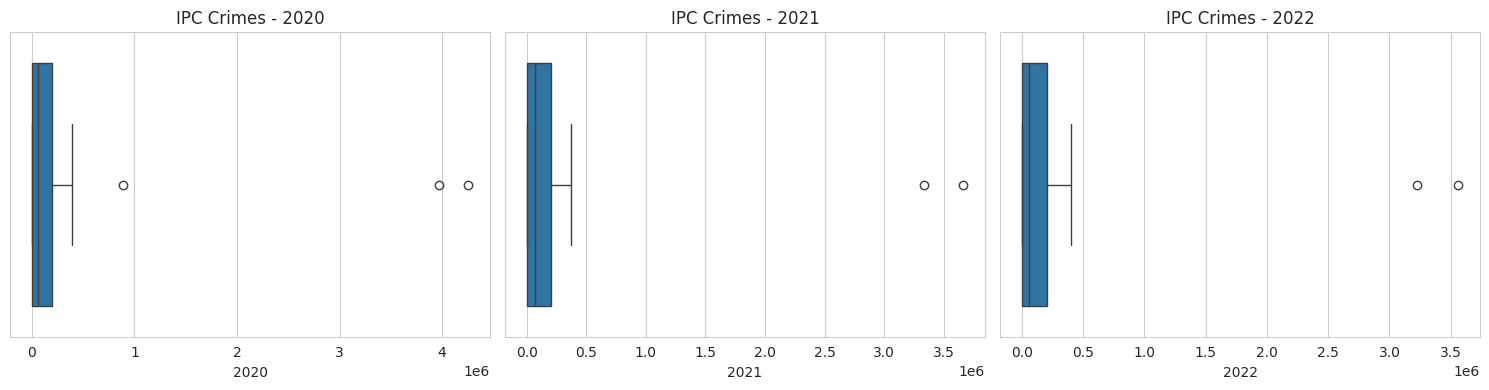

In [35]:
year_cols = ['2020', '2021', '2022']  # <-- update to match your actual column names

fig, axes = plt.subplots(1, len(year_cols), figsize=(15, 4))
for ax, col in zip(axes, year_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f'IPC Crimes - {col}')
plt.tight_layout()
plt.show()


### 3.5 Aggregate / Total Row Check
NCRB tables often include an 'All India' or 'Total' row mixed in with state rows.

In [36]:
mask_total = df[state_col].astype(str).str.contains('total|all india', case=False, na=False)
print(df[mask_total])


            Sl. No.         State/UT     2020     2021     2022  \
28  Total State (S)  Total State (S)  3969206  3336273  3226710   
37      Total UT(S)      Total UT(S)   285150   327087   334669   
38  Total All India  Total All India  4254356  3663360  3561379   

    Mid-Year Projected Population (in Lakhs) (2022)  \
28                                          13403.0   
37                                            394.5   
38                                          13797.5   

    Rate of Cognizable Crimes (IPC) (2022)  Chargesheeting Rate (2022)  
28                                   240.7                        74.9  
37                                   848.4                        35.6  
38                                   258.1                        71.3  


## 4. Data Cleaning & Preprocessing

### 4.1 Standardize State/UT Names

In [37]:
df[state_col] = df[state_col].astype(str).str.strip().str.title()


### 4.2 Fix Data Types (strip thousands separators, coerce to numeric)

In [38]:
for col in year_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[year_cols].dtypes


,0
2020,int64
2021,int64
2022,int64


### 4.3 Handle Missing Values
Filling with 0 reflects 'not reported' rather than fabricating a plausible value. Adjust this if your dataset's context calls for a different treatment.

In [39]:
df[year_cols] = df[year_cols].fillna(0)
df.isnull().sum()


,0
Sl. No.,0
State/UT,0
2020,0
2021,0
2022,0
Mid-Year Projected Population (in Lakhs) (2022),0
Rate of Cognizable Crimes (IPC) (2022),0
Chargesheeting Rate (2022),0


### 4.4 Separate the National Aggregate Row
Keep it for validation, but exclude it from state-wise comparisons.

In [40]:
national_total = df[mask_total].copy()
df_clean = df[~mask_total].reset_index(drop=True)
print('States/UTs remaining:', df_clean.shape[0])
national_total


States/UTs remaining: 36


,Sl. No.,State/UT,2020,2021,2022,Mid-Year Projected Population (in Lakhs) (2022),Rate of Cognizable Crimes (IPC) (2022),Chargesheeting Rate (2022)
28,Total State (S),Total State (S),3969206,3336273,3226710,13403.0,240.7,74.9
37,Total UT(S),Total Ut(S),285150,327087,334669,394.5,848.4,35.6
38,Total All India,Total All India,4254356,3663360,3561379,13797.5,258.1,71.3


### 4.5 Remove Duplicate Rows (if any)

In [41]:
df_clean = df_clean.drop_duplicates().reset_index(drop=True)
print('Duplicates remaining:', df_clean.duplicated().sum())


Duplicates remaining: 0


### 4.6 Reshape to Long/Tidy Format
Useful for year-over-year trend analysis and groupby operations.

In [42]:
df_long = df_clean.melt(id_vars=[state_col], value_vars=year_cols,
                         var_name='Year', value_name='IPC_Crimes')
df_long['Year'] = df_long['Year'].astype(int)
df_long.head()


,State/UT,Year,IPC_Crimes
0,Andhra Pradesh,2020,188997
1,Arunachal Pradesh,2020,2244
2,Assam,2020,111558
3,Bihar,2020,194698
4,Chhattisgarh,2020,65216


## 5. Validation
Sanity-check the cleaned data against the preserved national total.

In [43]:
reconstructed_total = df_clean[year_cols].sum()
print('Reconstructed totals from states:')
print(reconstructed_total)
print()
print('Published national total row:')
print(national_total[year_cols])


Reconstructed totals from states:
2020    4254356
2021    3663360
2022    3561379
dtype: int64

Published national total row:
       2020     2021     2022
28  3969206  3336273  3226710
37   285150   327087   334669
38  4254356  3663360  3561379


## 6. Analysis & Visualization

### 6.1 Top 10 States/UTs by Total IPC Crimes (2020–2022 combined)

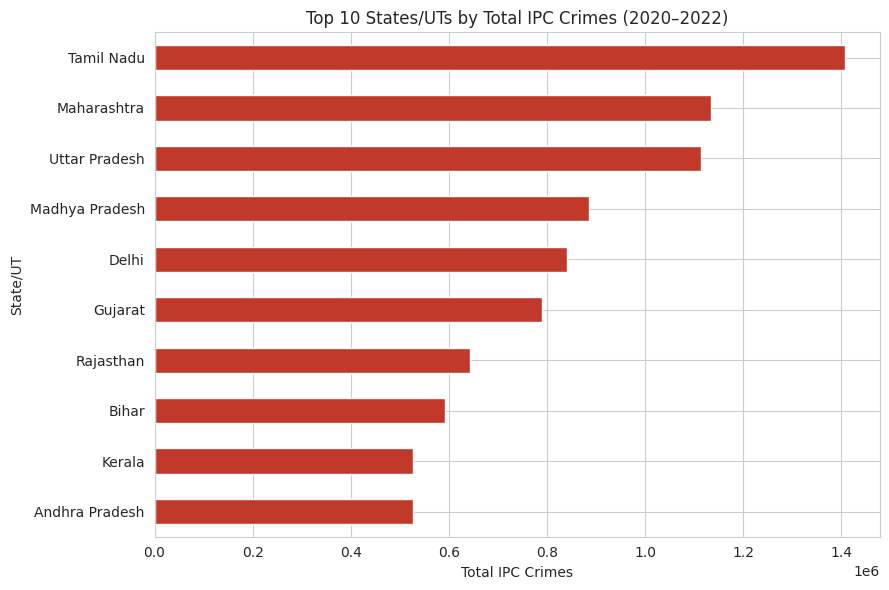

In [44]:
top10 = df_long.groupby(state_col)['IPC_Crimes'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
top10.sort_values().plot(kind='barh', color='#c0392b')
plt.title('Top 10 States/UTs by Total IPC Crimes (2020–2022)')
plt.xlabel('Total IPC Crimes')
plt.tight_layout()
plt.show()


### 6.2 National Year-over-Year Trend

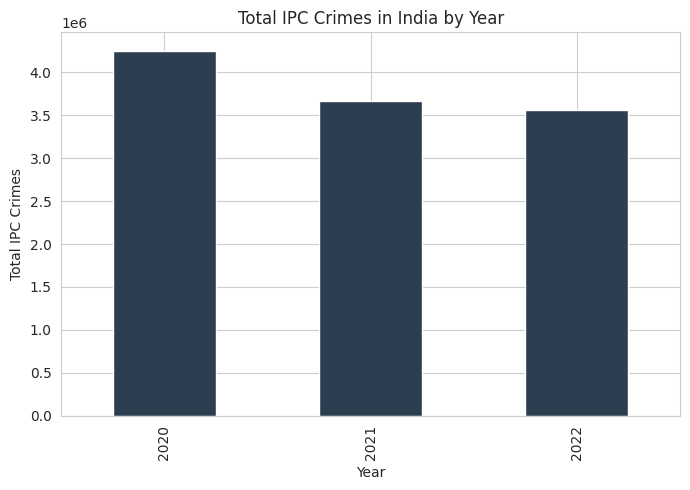

In [45]:
yearly_total = df_long.groupby('Year')['IPC_Crimes'].sum()

plt.figure(figsize=(7, 5))
yearly_total.plot(kind='bar', color='#2c3e50')
plt.title('Total IPC Crimes in India by Year')
plt.ylabel('Total IPC Crimes')
plt.tight_layout()
plt.show()


### 6.3 Trend for a Specific State
Change `state_name` below to explore any state/UT.

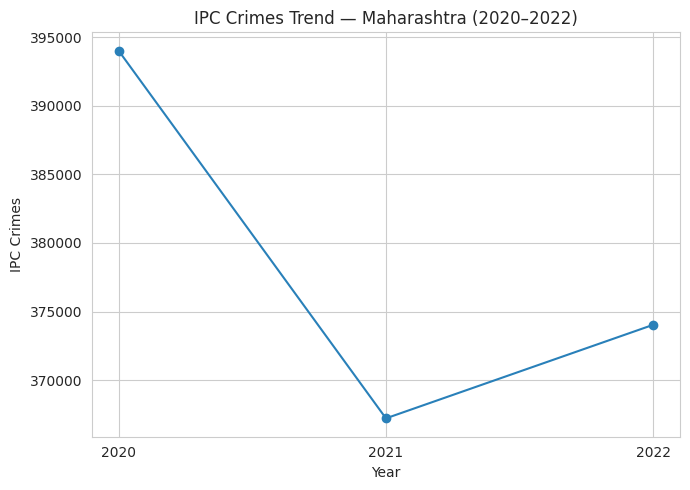

In [46]:
state_name = 'Maharashtra'  # <-- change as needed
state_data = df_long[df_long[state_col] == state_name]

plt.figure(figsize=(7, 5))
plt.plot(state_data['Year'], state_data['IPC_Crimes'], marker='o', color='#2980b9')
plt.title(f'IPC Crimes Trend — {state_name} (2020–2022)')
plt.xlabel('Year')
plt.ylabel('IPC Crimes')
plt.xticks(state_data['Year'])
plt.tight_layout()
plt.show()


## 7. Export Cleaned Data


In [47]:
df_clean.to_csv('IPC_Crimes_cleaned_wide.csv', index=False)
df_long.to_csv('IPC_Crimes_cleaned_long.csv', index=False)
print('Saved: IPC_Crimes_cleaned_wide.csv, IPC_Crimes_cleaned_long.csv')


Saved: IPC_Crimes_cleaned_wide.csv, IPC_Crimes_cleaned_long.csv
